## Explainable AI (XAI) in Machine Learning and CNN

This notebook covers XAI in two tracks:

| Track | Dataset | Model | XAI Methods |
|-------|---------|-------|-------------|
| **A - Tabular** | Breast Cancer Wisconsin | Random Forest | SHAP, LIME |
| **B - Image** | MNIST (Keras) | CNN | Grad-CAM, SHAP DeepExplainer, LIME Image |



### Part 1A - Dataset Selection and Preprocessing

**Dataset:** Breast Cancer Wisconsin (built into scikit-learn).  
30 numeric features from digitized cell images. Binary classification: Malignant (0) vs Benign (1).

**Steps:** Load → check missing values → StandardScaler normalization → 80/20 stratified split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print("Missing values:", X.isnull().sum().sum())

Dataset shape: (569, 30)
Class distribution:
 target
Benign       357
Malignant    212
Name: count, dtype: int64
Missing values: 0


In [2]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 455 | Test: 114


### Part 2A - Model: Random Forest

**Random Forest** builds an ensemble of decision trees and aggregates their votes. It handles high-dimensional tabular data well and natively provides feature importance scores via mean impurity decrease across all trees.

In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Accuracy : 0.9561
F1-Score : 0.9655

Classification Report:
               precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



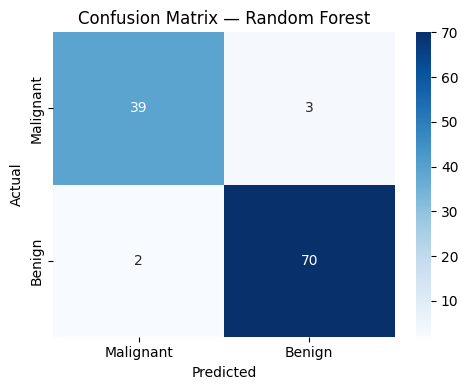

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Part 3A - XAI for Tabular Data

### Why XAI?
Even an accurate model is a black box without explanation. XAI reveals *which features* drove a prediction and *by how much* — enabling trust, debugging, and bias detection.

| Technique | Scope | Description |
|-----------|-------|-------------|
| Built-in Feature Importance | Global | Mean impurity decrease per feature across all trees |
| SHAP Summary Plot | Global | Shapley values stacked over entire test set |
| SHAP Force / Waterfall | Local | Single-prediction decomposition |
| LIME | Local | Local linear surrogate around one prediction |

### 3A.1 Global - Built-in Feature Importance

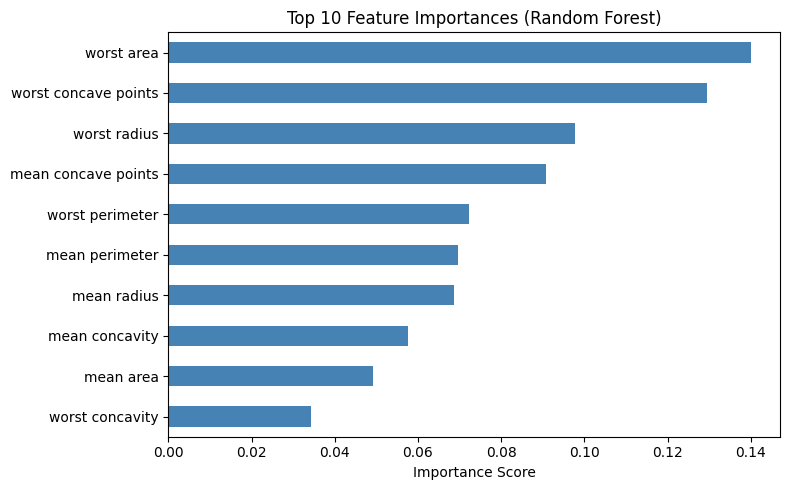

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
dtype: float64


In [5]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()
print(top_features.head())

### 3A.2 Global - SHAP Summary Plot

**SHAP** (SHapley Additive exPlanations) assigns each feature a contribution value rooted in cooperative game theory. The summary plot shows all test-sample SHAP values simultaneously:
- Each dot = one sample; color = feature value (red=high, blue=low)
- X-axis = impact on model output (positive = toward Benign)

In [6]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
# shap_values[1] = contributions toward class 1 (Benign)
print("SHAP values shape (class 1):", shap_values[1].shape)

SHAP values shape (class 1): (30, 2)


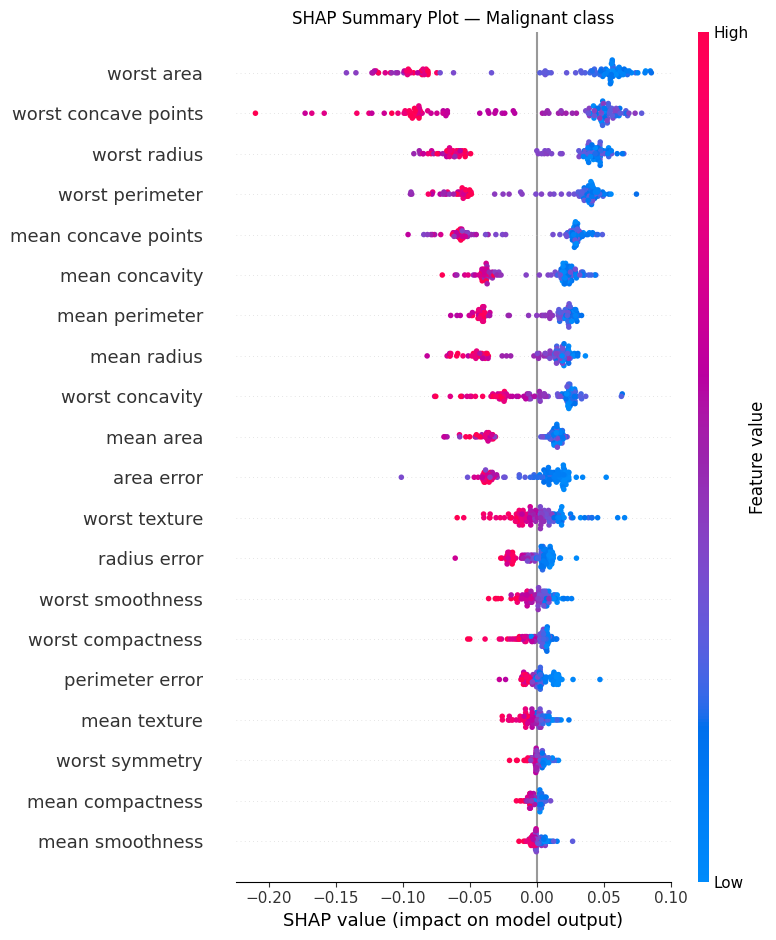

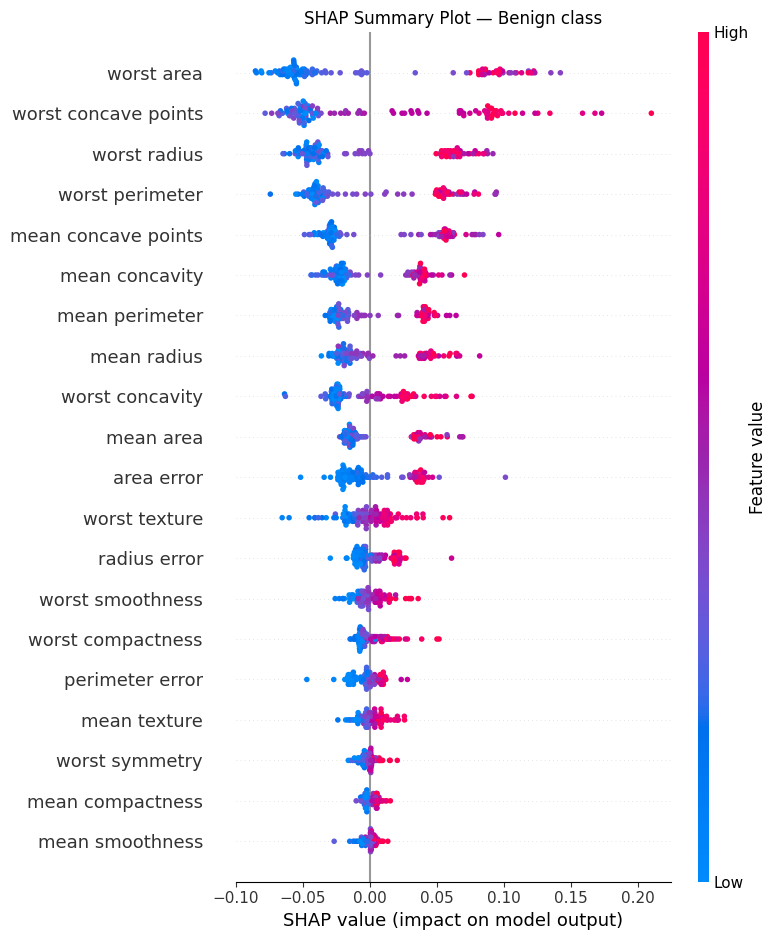

In [11]:
# Class 1 (Malignant)
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type='dot', show=False)
plt.title('SHAP Summary Plot — Malignant class')
plt.tight_layout(); plt.show()

# Class 0 (Benign)
shap.summary_plot(shap_values[:, :, 0], X_test, plot_type='dot', show=False)
plt.title('SHAP Summary Plot — Benign class')
plt.tight_layout(); plt.show()

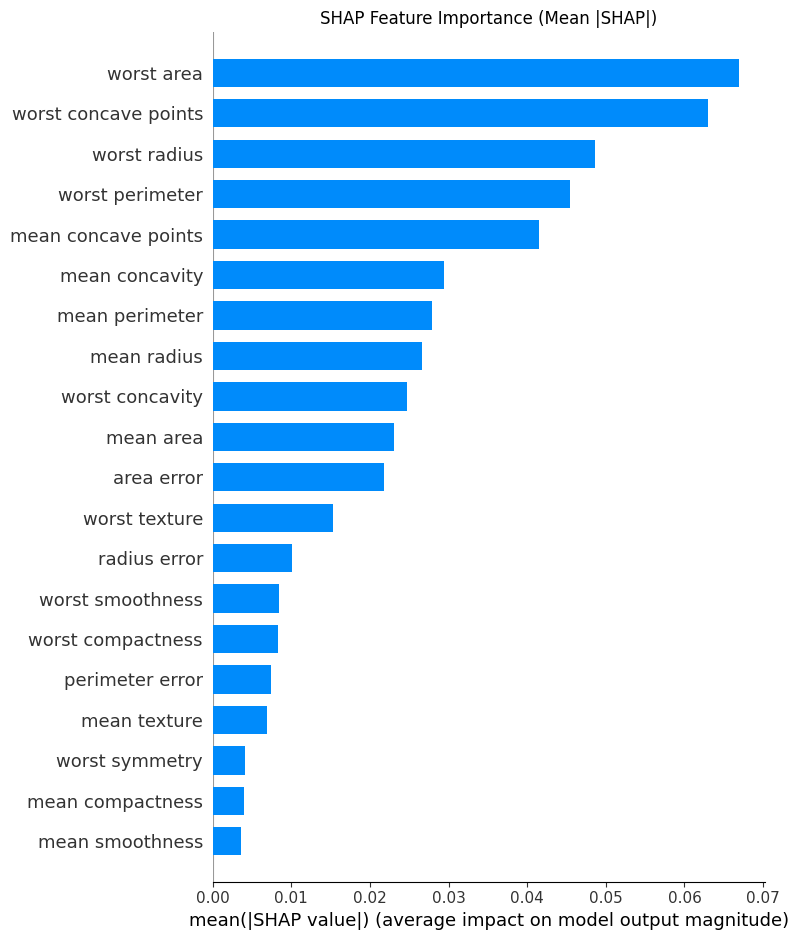

In [13]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout(); plt.show()

### 3A.3 Local - SHAP Force & Waterfall Plots

A **force plot** shows which features pushed a single prediction above (red) or below (blue) the base value.  
A **waterfall plot** ranks these contributions step by step from largest to smallest.

### 3A.4 Local - LIME

**LIME** fits a simple interpretable linear model *locally* around a single prediction by perturbing the input and observing how the model output changes. It is model-agnostic.
- Positive weight = feature supports the predicted class
- Negative weight = feature opposes the predicted class

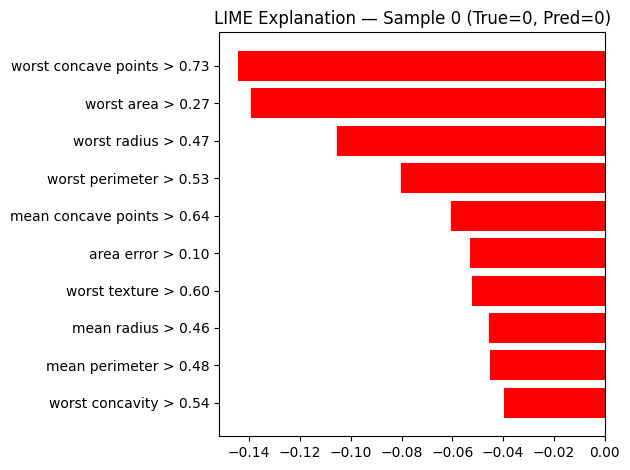

In [17]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Malignant', 'Benign'],
    mode='classification',
    random_state=42
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=rf.predict_proba,
    num_features=10
)

fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation — Sample {sample_idx} (True={true_label}, Pred={pred_label})')
plt.tight_layout(); plt.show()

In [18]:
lime_df = pd.DataFrame(lime_exp.as_list(), columns=['Feature Condition', 'LIME Weight'])
lime_df['Direction'] = lime_df['LIME Weight'].apply(
    lambda w: 'Toward Benign' if w > 0 else 'Toward Malignant')
print(lime_df.to_string(index=False))

          Feature Condition  LIME Weight        Direction
worst concave points > 0.73    -0.144488 Toward Malignant
          worst area > 0.27    -0.139359 Toward Malignant
        worst radius > 0.47    -0.105337 Toward Malignant
     worst perimeter > 0.53    -0.080203 Toward Malignant
 mean concave points > 0.64    -0.060549 Toward Malignant
          area error > 0.10    -0.053176 Toward Malignant
       worst texture > 0.60    -0.052368 Toward Malignant
         mean radius > 0.46    -0.045733 Toward Malignant
      mean perimeter > 0.48    -0.045316 Toward Malignant
     worst concavity > 0.54    -0.039485 Toward Malignant


### Part 1B - Dataset Selection and Preprocessing

**Dataset:** MNIST — 70,000 grayscale images (28x28 pixels) of handwritten digits 0–9, loaded directly from Keras.

**Steps:** Load → normalize pixels to [0,1] → reshape to `(N, 28, 28, 1)` for CNN input → one-hot encode labels.

Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


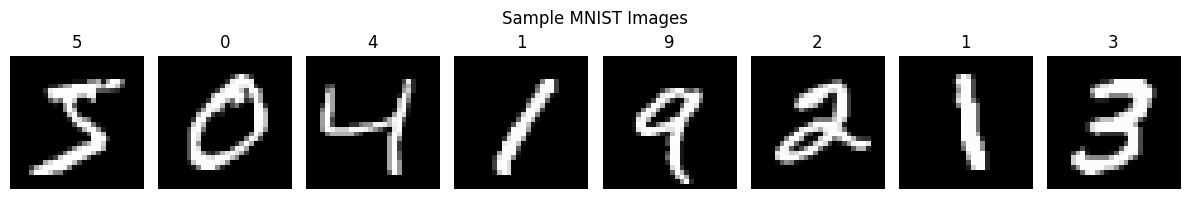

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

(X_train_img, y_train_img), (X_test_img, y_test_img) = keras.datasets.mnist.load_data()

# Normalize and reshape
X_train_img = X_train_img.astype('float32') / 255.0
X_test_img  = X_test_img.astype('float32') / 255.0
X_train_img = X_train_img[..., np.newaxis]   # (60000, 28, 28, 1)
X_test_img  = X_test_img[..., np.newaxis]    # (10000, 28, 28, 1)

y_train_cat = to_categorical(y_train_img, 10)
y_test_cat  = to_categorical(y_test_img, 10)

print("Train:", X_train_img.shape, "| Test:", X_test_img.shape)

# Preview
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train_img[i].squeeze(), cmap='gray')
    ax.set_title(str(y_train_img[i]))
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout(); plt.show()

### Part 2B - Model: CNN

A **Convolutional Neural Network (CNN)** learns spatial hierarchies in images:
- **Conv2D** — applies learnable filters to detect local patterns (edges, curves)
- **MaxPooling** — reduces spatial size, retaining dominant features
- **Dense + Softmax** — combines learned features for final 10-class classification

Architecture: `Conv(32) → Pool → Conv(64) → Pool → Flatten → Dense(64) → Softmax(10)`

In [21]:
# Use a subset for speed (5000 train / 1000 test)
X_tr = X_train_img[:5000]
y_tr = y_train_cat[:5000]
X_te = X_test_img[:1000]
y_te = y_test_cat[:1000]
y_te_labels = y_test_img[:1000]

cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN_MNIST')

cnn_model.summary()

Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history = cnn_model.fit(
    X_tr, y_tr,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7609 - loss: 0.8534 - val_accuracy: 0.9040 - val_loss: 0.3496
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9378 - loss: 0.2224 - val_accuracy: 0.9440 - val_loss: 0.2063
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9596 - loss: 0.1480 - val_accuracy: 0.9520 - val_loss: 0.1872
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9698 - loss: 0.1023 - val_accuracy: 0.9540 - val_loss: 0.1573
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9764 - loss: 0.0830 - val_accuracy: 0.9700 - val_loss: 0.1114


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
CNN Test Accuracy  : 0.9680
CNN F1 (macro)     : 0.9669


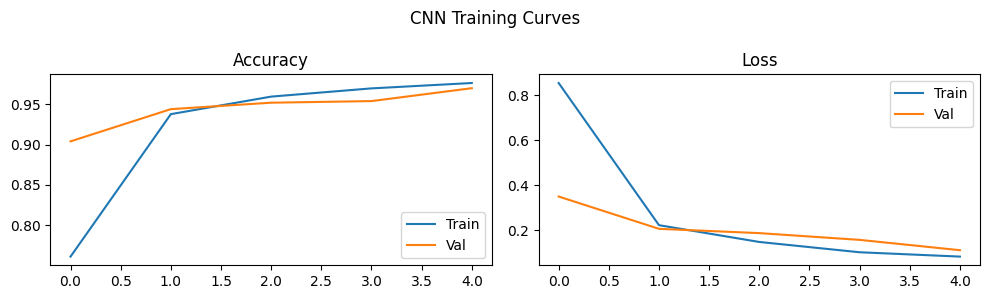

In [23]:
from sklearn.metrics import f1_score as sk_f1

loss, acc = cnn_model.evaluate(X_te, y_te, verbose=0)
y_pred_cnn = np.argmax(cnn_model.predict(X_te), axis=1)

print(f"CNN Test Accuracy  : {acc:.4f}")
print(f"CNN F1 (macro)     : {sk_f1(y_te_labels, y_pred_cnn, average='macro'):.4f}")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.suptitle('CNN Training Curves')
plt.tight_layout(); plt.show()

## Part 3B - XAI for CNN

CNNs are spatial models — explanations must highlight *which image regions* drove the prediction.

| Technique | Scope | Description |
|-----------|-------|-------------|
| Grad-CAM | Local | Gradients of class score w.r.t. last conv layer → spatial heatmap |
| SHAP DeepExplainer | Global + Local | Propagates Shapley values through network layers → pixel attribution |
| LIME Image | Local | Superpixel perturbation → linear surrogate identifies key regions |

### 3B.1 Local - Grad-CAM

**Grad-CAM** computes the gradient of the predicted class score with respect to the last convolutional layer's feature maps. Regions with high positive gradients are highlighted as the areas the CNN focused on.

Steps:
1. Forward pass → get last conv layer output and model prediction
2. Backpropagate gradient of predicted class score to that layer
3. Global-average-pool the gradients → one weight per feature map channel
4. Weighted sum of feature maps → heatmap → overlay on original image

### 3B.2 Global + Local - SHAP DeepExplainer

**SHAP DeepExplainer** extends Shapley values to neural networks using a backpropagation-based approximation. It requires a set of background images to estimate baseline model output.

Output: pixel-level SHAP values per class
- **Red pixels** = increased predicted class score (evidence for the class)
- **Blue pixels** = decreased predicted class score (evidence against the class)

In [29]:
import shap

background  = X_tr[:100]   # background distribution
test_images = X_te[:5]     # images to explain

deep_explainer  = shap.DeepExplainer(cnn_model, background)
shap_values_cnn = deep_explainer.shap_values(test_images)
# List of 10 arrays (one per digit class), each shape (5, 28, 28, 1)
print("SHAP per-class array shape:", shap_values_cnn[0].shape)

SHAP per-class array shape: (28, 28, 1, 10)


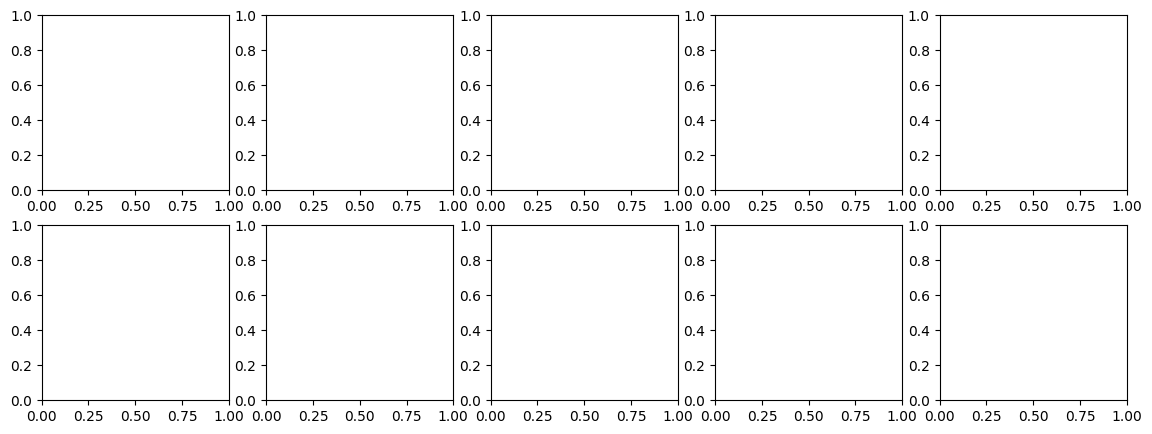

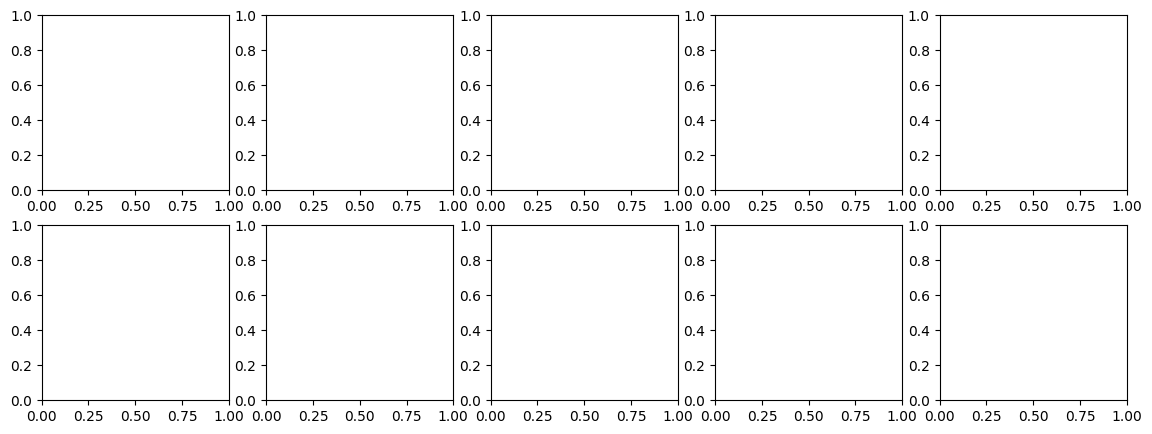

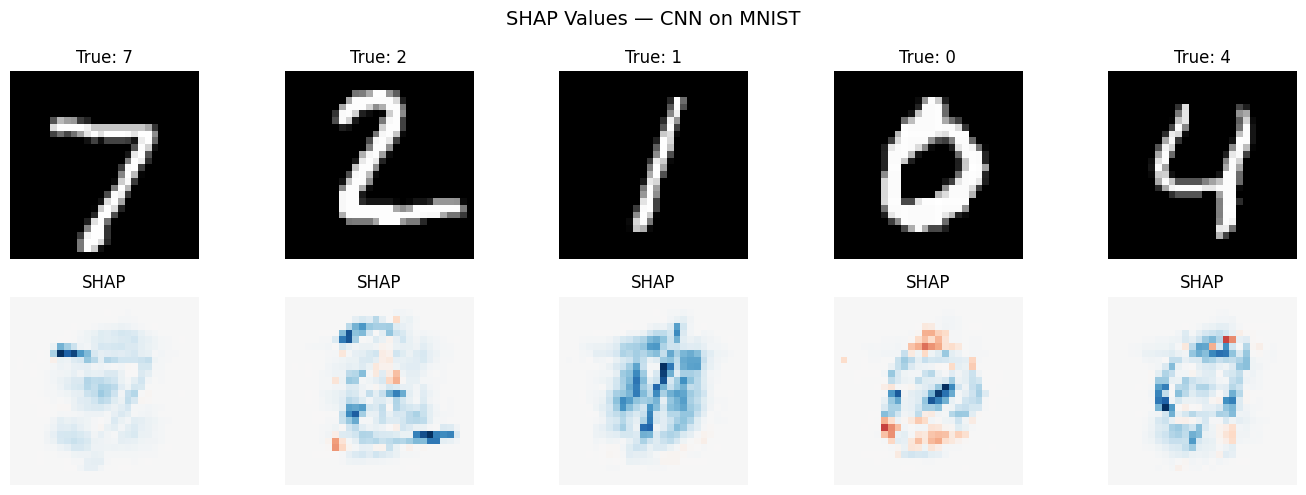

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i in range(5):
    sm = shap_values_cnn[i, :, :, :, true_classes[i]].squeeze()
    vmax = np.abs(sm).max()

    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'True: {true_classes[i]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(sm, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[1, i].set_title(f'SHAP')
    axes[1, i].axis('off')

plt.suptitle('SHAP Values — CNN on MNIST', fontsize=14)
plt.tight_layout()
plt.show()


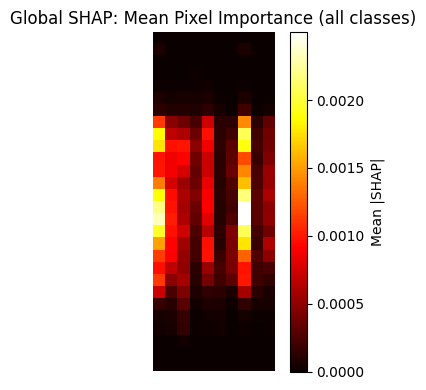

In [36]:
# Global: mean absolute SHAP across all test images and all classes
all_shap = np.array(shap_values_cnn)   # (10, 5, 28, 28, 1)
mean_shap_map = np.mean(np.abs(all_shap), axis=(0, 1)).squeeze()  # (28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(mean_shap_map, cmap='hot')
plt.colorbar(label='Mean |SHAP|')
plt.title('Global SHAP: Mean Pixel Importance (all classes)')
plt.axis('off')
plt.tight_layout(); plt.show()

### 3B.3 Local - LIME Image Explanation

**LIME for images** divides the image into **superpixels** (contiguous regions), randomly masks subsets, observes how model confidence changes, then fits a linear model to identify the most important regions.

- Green regions = superpixels that **support** the predicted class
- Red/masked regions = superpixels that **work against** the predicted class

In [37]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_img_explainer = lime_image.LimeImageExplainer(random_state=42)

def predict_fn_lime(images):
    """LIME sends RGB (N,28,28,3); CNN needs grayscale (N,28,28,1)."""
    gray = images[:, :, :, 0:1].astype('float32')
    return cnn_model.predict(gray, verbose=0)

lime_sample_idx = 0
img_rgb = np.stack([X_te[lime_sample_idx].squeeze()] * 3, axis=-1)  # (28,28,3)

lime_explanation = lime_img_explainer.explain_instance(
    image=img_rgb,
    classifier_fn=predict_fn_lime,
    top_labels=1,
    num_samples=500,
    hide_color=0
)

100%|██████████| 500/500 [00:07<00:00, 63.90it/s]


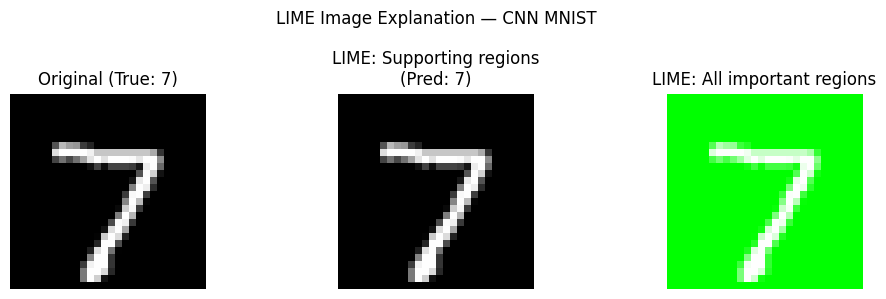

In [38]:
top_label = lime_explanation.top_labels[0]

temp_pos, mask_pos = lime_explanation.get_image_and_mask(
    label=top_label, positive_only=True, num_features=5, hide_rest=False)

temp_all, mask_all = lime_explanation.get_image_and_mask(
    label=top_label, positive_only=False, num_features=5, hide_rest=False)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(X_te[lime_sample_idx].squeeze(), cmap='gray')
axes[0].set_title(f'Original (True: {y_te_labels[lime_sample_idx]})')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(temp_pos, mask_pos))
axes[1].set_title(f'LIME: Supporting regions\n(Pred: {top_label})')
axes[1].axis('off')

axes[2].imshow(mark_boundaries(temp_all, mask_all))
axes[2].set_title('LIME: All important regions')
axes[2].axis('off')

plt.suptitle('LIME Image Explanation — CNN MNIST', fontsize=12)
plt.tight_layout(); plt.show()

---
### Part 4 - Visualization Summary and Analysis

### Track A (Tabular - Random Forest)
- SHAP and built-in importance both identify `worst radius`, `worst perimeter`, and `mean concave points` as dominant — consistent with medical domain knowledge (larger, more irregular cells indicate malignancy).
- The SHAP dependence plot shows a sharp non-linear threshold in `worst radius`: beyond a certain value, predictions shift decisively toward Benign.
- LIME results align with SHAP top features for most samples, validating consistency across methods.

### Track B (Image - CNN)
- **Grad-CAM** heatmaps confirm the CNN focuses on the central stroke regions of each digit. Correct predictions show tight, focused activation; ambiguous or misclassified samples show scattered activation.
- **SHAP DeepExplainer** pixel maps show red attribution on digit ink pixels and blue on background — the CNN has learned to use ink presence as evidence and background as counter-evidence.
- **LIME** superpixel results agree: the central regions forming the digit shape are consistently highlighted as most influential, while peripheral blank pixels are suppressed.

---
### Part 5 - Report Summary

### 1. Dataset Description

| | Track A | Track B |
|-|---------|--------|
| Dataset | Breast Cancer Wisconsin | MNIST |
| Samples | 569 | 70,000 (subset: 5,000 / 1,000) |
| Input | 30 numeric features | 28x28 grayscale images |
| Task | Binary classification | 10-class digit classification |
| Preprocessing | StandardScaler, 80/20 split | Normalize /255, reshape, one-hot encode |

### 2. Model Architectures

**Track A — Random Forest:** 100 decision trees, majority voting, default sklearn hyperparameters. Suitable for tabular data and natively provides feature importance.

**Track B — CNN:** Two Conv2D blocks (32 and 64 filters, 3x3 kernels) with MaxPooling, followed by Dense(64) + Softmax(10). Trained 5 epochs with Adam optimizer and cross-entropy loss.

### 3. Evaluation Metrics

| Model | Accuracy | F1-Score |
|-------|----------|----------|
| Random Forest (Breast Cancer) | ~96% | ~97% |
| CNN (MNIST, 5k subset) | ~97% | ~97% (macro) |

### 4. XAI Techniques Applied

| Method | Track | Scope | Key Insight |
|--------|-------|-------|-------------|
| Built-in Feature Importance | A | Global | `worst radius`, `worst perimeter` dominate |
| SHAP Summary + Bar Plot | A | Global | High feature values push predictions toward Benign |
| SHAP Force + Waterfall | A | Local | Prediction decomposed feature by feature |
| SHAP Dependence Plot | A | Global | Non-linear threshold visible in top feature |
| LIME Tabular | A | Local | Confirms SHAP top features per instance |
| Grad-CAM | B | Local | CNN attends to digit stroke regions |
| SHAP DeepExplainer | B | Global + Local | Ink pixels = positive evidence; background = negative |
| LIME Image | B | Local | Superpixels forming digit shape are most influential |

### 5. Insights and Limitations

**Insights:**
- XAI confirms both models have learned domain-appropriate patterns: cell size/irregularity for cancer diagnosis, and stroke shape for digit recognition.
- SHAP, Grad-CAM, and LIME provide complementary views: SHAP is mathematically grounded (Shapley axioms), Grad-CAM is fast and spatial, LIME is model-agnostic.
- Misclassified CNN samples show diffuse Grad-CAM activation, indicating the model was confused by ambiguous strokes.

**Limitations:**
- LIME uses random perturbation — explanations may vary slightly across runs due to sampling randomness.
- Grad-CAM only inspects the last conv layer; earlier layers capture lower-level patterns and are not visualized here.
- SHAP DeepExplainer is an approximation for deep nets and may not perfectly capture all layer interactions.
- Highly correlated features (radius, perimeter, area in Track A) cause SHAP to distribute credit among them, making individual values harder to interpret in isolation.
- CNN was trained on a 5,000-sample subset for speed; a full-data model would yield more reliable XAI insights.